# How does Bayesian estimation respond to the same batting average across different sample sizes

## Imports and Prior Setup

In [8]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
from scipy.stats import beta 

import sys
sys.path.append("..")

from src.bayesian_batting import (
    batting_summary,
    posterior_parameters,
)

prior_alpha = 25
prior_beta = 75

## Experiment 1

I use a beta(25, 75) prior, that is a prior batting average of 0.250. 25 hits and 75 outs. So 100 at bats of previous information

Now, let's run an experiment considering 'new data', all with a naive batting average of 0.600. Let's spread it out across multiple sample sizes to evaluate how the Bayesian average changes.

In [16]:
examples = [
    (3,5),
    (6,10),
    (30,50),
    (60,100),
    (300,500),
]

summaries = []

#loop over example 'new data'
for hits, at_bats in examples:
    #use the batting_summary function to return information about the new Bayesian average
    summary = batting_summary(
        hits,
        at_bats,
        prior_alpha,
        prior_beta,
    )
    summaries.append(summary)

#represent the information about the new Bayesian average in a table
df = pd.DataFrame(summaries)

#tidy table, round values to make reading easier
results = df[
    [
        "hits",
        "at_bats",
        "naive_average",
        "posterior_mean",
        "posterior_std",
        "credible_interval_lower",
        "credible_interval_upper",
    ]
].copy()

results["naive_average"] = results["naive_average"].round(3)
results["posterior_mean"] = results["posterior_mean"].round(3)
results["posterior_std"] = results["posterior_std"].round(3)
results["credible_interval_lower"] = results["credible_interval_lower"].round(3)
results["credible_interval_upper"] = results["credible_interval_upper"].round(3)
results["credible_interval_width"] = (
    results["credible_interval_upper"] - results["credible_interval_lower"]
)

results

,hits,at_bats,naive_average,posterior_mean,posterior_std,credible_interval_lower,credible_interval_upper,credible_interval_width
0,3,5,0.6,0.259,0.043,0.181,0.346,0.165
1,6,10,0.6,0.267,0.043,0.191,0.351,0.160
2,30,50,0.6,0.306,0.043,0.241,0.375,0.134
3,60,100,0.6,0.327,0.043,0.271,0.385,0.114
4,300,500,0.6,0.361,0.043,0.330,0.393,0.063


### Plotting results for experiment 1

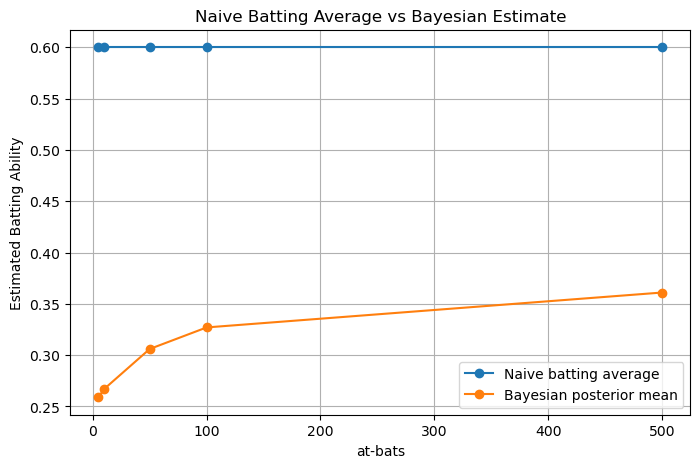

In [20]:
plt.figure(figsize=(8,5))

#plot a line for naive bating average as at_bats increases
plt.plot(
    results["at_bats"],
    results["naive_average"],
    marker="o",
    label="Naive batting average"
)
#plot a line for bayesian batting average as at_bats increases
plt.plot(
    results["at_bats"],
    results["posterior_mean"],
    marker="o",
    label="Bayesian posterior mean"
)

plt.xlabel("at-bats")
plt.ylabel("Estimated Batting Ability")
plt.title("Naive Batting Average vs Bayesian Estimate")
plt.legend()
plt.grid(True)
plt.show()


The naive average stays fixed at 0.600, while the Bayesian estimate starts much lower and moves toward .600 as the sample size increases

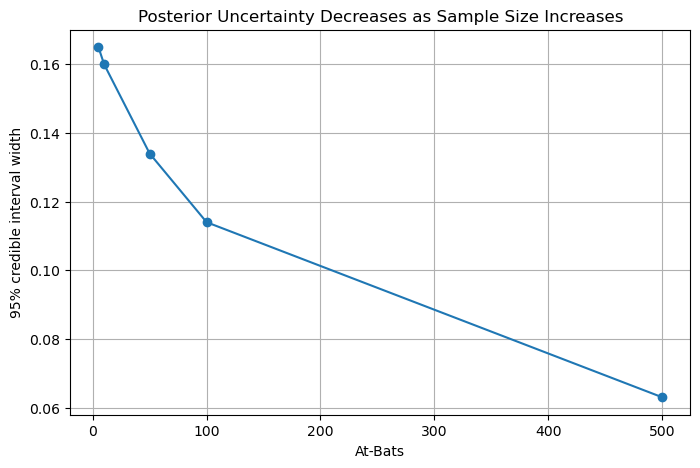

In [21]:
plt.figure(figsize=(8,5))

plt.plot(
    results["at_bats"],
    results["credible_interval_width"],
    marker="o"
)

plt.xlabel("At-Bats")
plt.ylabel("95% credible interval width")
plt.title("Posterior Uncertainty Decreases as Sample Size Increases")
plt.grid(True)
plt.show()

As sample size increases, the credible interval becomes narrower, meaning the model becomes more certain about the player's true batting ability.

Now, let's see how prior vs posterior changes for one example. In other words, how does adding new data affect the Bayesian average?

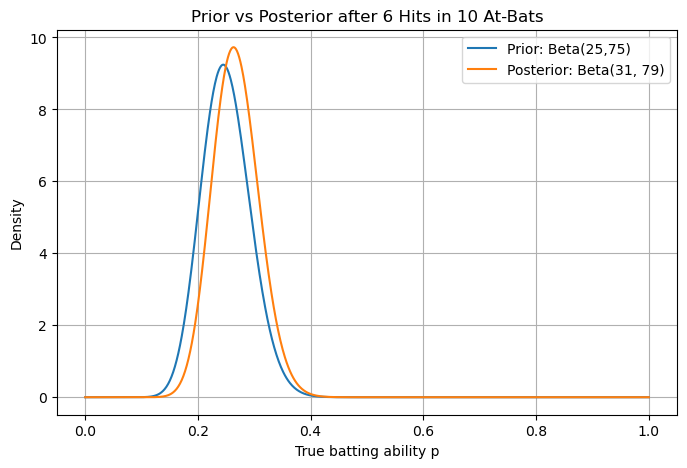

In [24]:
hits = 6
at_bats = 10

#calculate posterior parameters
posterior_alpha, posterior_beta = posterior_parameters(
    prior_alpha,
    prior_beta,
    hits=hits,
    at_bats=at_bats,
)

#create 1000 evenly spaced numbers between 1 and 0, to represent avg
x = np.linspace(0,1,1000)

#use the prior density function to calculate 
#the height of the prior Beta Distribution at each value of x
prior_density = beta.pdf(x, prior_alpha, prior_beta)

#again for the posterior Beta Distribution 
posterior_density = beta.pdf(x, posterior_alpha, posterior_beta)

plt.figure(figsize=(8, 5))

plt.plot(x, prior_density, label="Prior: Beta(25,75)")
plt.plot(x, posterior_density, label="Posterior: Beta(31, 79)")

plt.xlabel("True batting ability p")
plt.ylabel("Density")
plt.title("Prior vs Posterior after 6 Hits in 10 At-Bats")
plt.legend()
plt.grid(True)
plt.show()




After a small sample size increase, the posterior average shifts to the right because going 6/10 is strong short-term evidence. However, it does not move all the way to .600 because the sample size is small.